In [2]:
import os
import json
import warnings
import numpy as np
import xarray as xr
import proplot as pplt
warnings.filterwarnings('ignore')
pplt.rc.update({
    'tick.minor':False,
    'savefig.dpi':300,
    'font.size':9,
    'label.size':9,
    'tick.labelsize':9,
    'legend.fontsize':9,
    'leftlabelsize':9,
    'toplabelsize':9,
    'leftlabel.weight':'normal',
    'toplabel.weight':'normal',
    'reso':'xx-hi'})

In [ ]:
with open('../scripts/configs.json','r',encoding='utf-8') as f:
    CONFIGS = json.load(f)
SPLITSDIR = CONFIGS['filepaths']['splits']
PREDSDIR  = CONFIGS['filepaths']['predictions']
LATRANGE  = CONFIGS['domain']['latrange']
LONRANGE  = CONFIGS['domain']['lonrange']
SPLIT     = 'valid'
_MODELS   = CONFIGS['experiments']

MODELDICT = {
    'pod_bl':      {'label':_MODELS['pod']['runs']['pod_bl'].get('description','POD-BL'),              'color':'k'},
    'nn_bl':       {'label':_MODELS['nn']['runs']['nn_bl'].get('description','NN-BL'),                 'color':'#fa862d'},
    'nn_full':     {'label':_MODELS['nn']['runs']['nn_full'].get('description','NN-FULL'),             'color':'#1b2c63'},
    'nn_nonparam': {'label':_MODELS['nn']['runs']['nn_nonparam'].get('description','NN-NONPARAM'),     'color':'#245ba7'},
    'nn_gauss':    {'label':_MODELS['nn']['runs']['nn_gauss'].get('description','NN-GAUSS'),           'color':'#5ca7db'},
    'sr_bl':       {'label':_MODELS['sr']['optimizedeqs']['sr_bl'].get('description','SR-BL'),         'color':'#c41d24'},
    'sr_lo':       {'label':_MODELS['sr']['optimizedeqs']['sr_lo'].get('description','SR-LO'),         'color':'#921519'},
    'sr_med':      {'label':_MODELS['sr']['optimizedeqs']['sr_med'].get('description','SR-MED'),       'color':'#fce998'},
    'sr_hi':       {'label':_MODELS['sr']['optimizedeqs']['sr_hi'].get('description','SR-HI'),         'color':'#a3ddf7'},
}

In [4]:
with xr.open_dataset(os.path.join(SPLITSDIR,f'{SPLIT}.h5'),engine='h5netcdf') as ds:
    truetp = ds.tp.load()

results = {}
for name in MODELDICT:
    filepath = os.path.join(PREDSDIR,f'{name}_{SPLIT}_predictions.nc')
    if not os.path.exists(filepath):
        print(f'Missing: {name}')
        continue
    with xr.open_dataset(filepath) as ds:
        pred = ds.tp.load()
    if 'seed' in pred.dims:
        pred = pred.mean('seed')
    if 'complexity' in pred.dims:
        pred = pred.isel(complexity=0)
    ytrue,ypred   = xr.align(truetp,pred,join='inner')
    results[name] = (ytrue.squeeze(),ypred.squeeze())

print(f'Loaded {len(results)}/{len(MODELDICT)} models')

Loaded 8/8 models


## Approach 1: Exceedance probability curves

Plot the empirical survival function P(X > x) on a log–log scale for each model alongside the observed distribution. This directly reveals whether a model captures the heavy tail of the rainfall distribution.

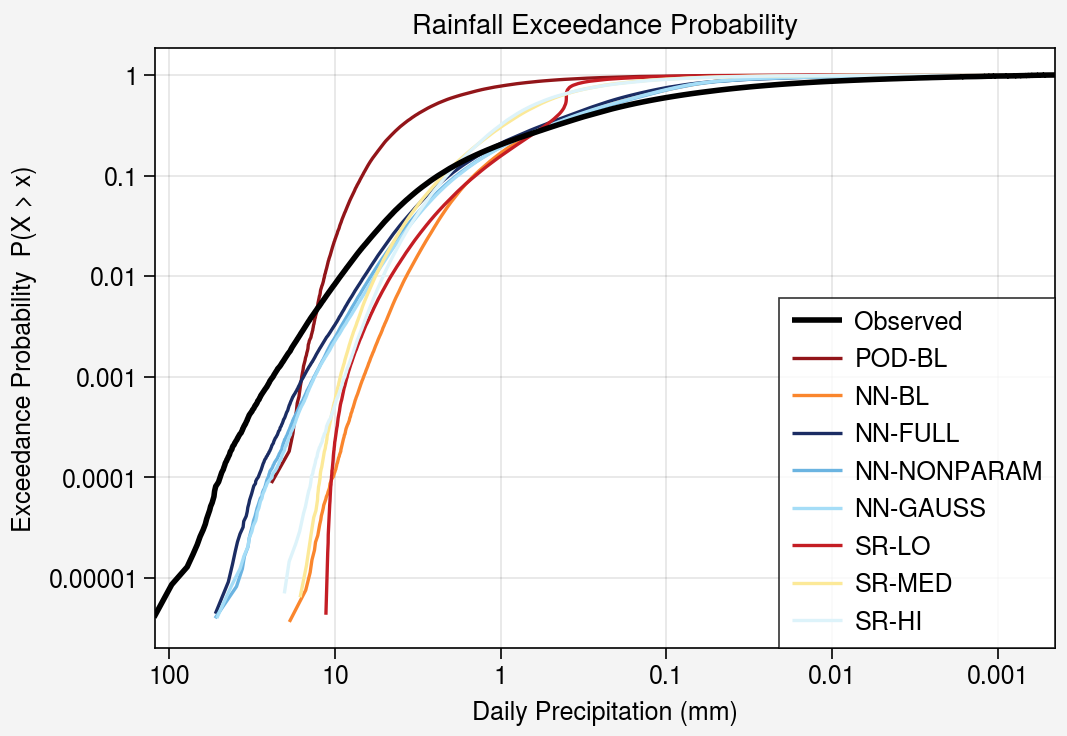

In [9]:
def exceedance_curve(arr,subsample=5):
    '''Return (sorted_values_desc, exceedance_probs) for positive finite values.'''
    flat = arr.ravel()
    flat = flat[np.isfinite(flat) & (flat > 0)]
    flat = np.sort(flat)[::-1][::subsample]
    prob = np.arange(1,len(flat)+1) / len(flat)
    return flat,prob

ytrue_ref = next(iter(results.values()))[0]
obs_x,obs_p = exceedance_curve(ytrue_ref.values)

fig,ax = pplt.subplots(refwidth=4.5,refheight=3)
ax.plot(obs_x,obs_p,color='k',lw=2,label='Observed',zorder=10)
for name,info in MODELDICT.items():
    if name not in results:
        continue
    pred_x,pred_p = exceedance_curve(results[name][1].values)
    ax.plot(pred_x,pred_p,color=info['color'],lw=1.2,label=info['label'])
ax.format(
    xlabel='Daily Precipitation (mm)',
    ylabel='Exceedance Probability  P(X > x)',
    xscale='log',yscale='log',
    grid=True,title='Rainfall Exceedance Probability')
ax.legend(loc='lr',ncols=1)
pplt.show()
# fig.save('../figs/fig_S_extremes_exceedance.jpg')

## Approach 2: Quantile ratio curves

For each percentile from the 50th to the 99.9th, compute the ratio of the model's quantile to the observed quantile. A ratio of 1 is perfect; values above 1 indicate the model is over-predicting that intensity level. This curve pinpoints *where* in the distribution each model breaks down.

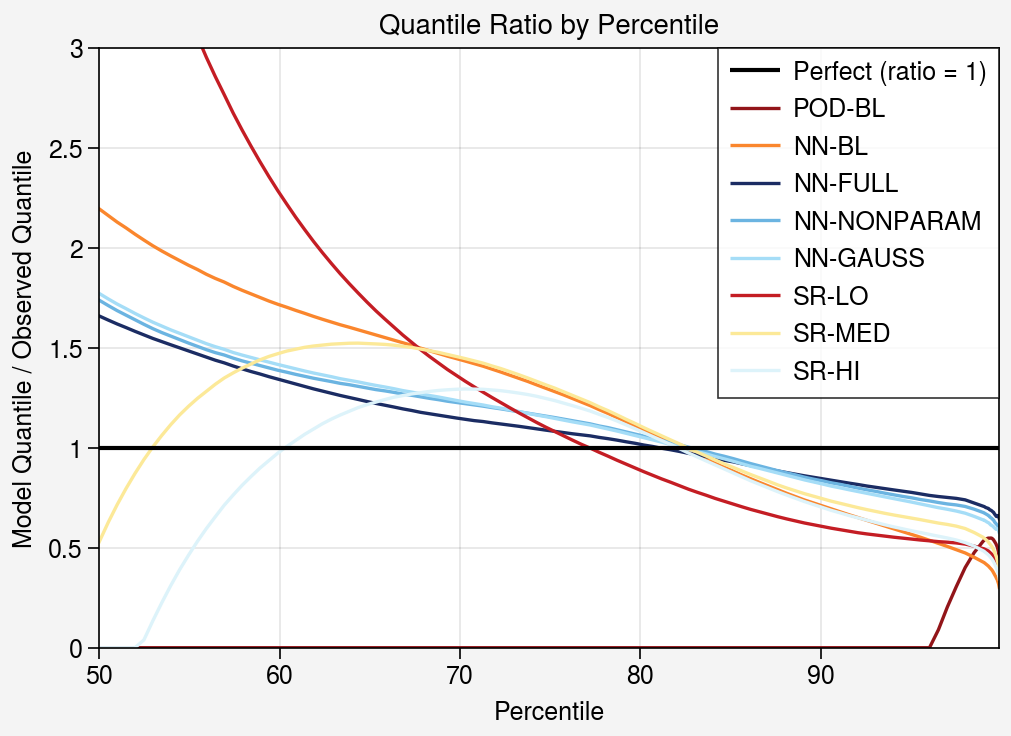

In [10]:
qs = np.concatenate([np.linspace(50,99,100),np.linspace(99,99.9,50)])

ytrue_ref   = next(iter(results.values()))[0]
obs_flat    = ytrue_ref.values.ravel()
obs_flat    = obs_flat[np.isfinite(obs_flat)]
obs_qs      = np.nanpercentile(obs_flat,qs)

fig,ax = pplt.subplots(refwidth=4.5,refheight=3)
ax.axhline(1.0,color='k',lw=1.5,linestyle='-',label='Perfect (ratio = 1)',zorder=10)
for name,info in MODELDICT.items():
    if name not in results:
        continue
    pred_flat = results[name][1].values.ravel()
    pred_flat = pred_flat[np.isfinite(pred_flat)]
    pred_qs   = np.nanpercentile(pred_flat,qs)
    safe_obs  = np.where(obs_qs > 0,obs_qs,np.nan)
    ax.plot(qs,pred_qs/safe_obs,color=info['color'],lw=1.2,label=info['label'])
ax.format(
    xlabel='Percentile',
    ylabel='Model Quantile / Observed Quantile',
    xlim=(50,99.9),ylim=(0,3),
    grid=True,title='Quantile Ratio by Percentile')
ax.legend(loc='ur',ncols=1)
pplt.show()
# fig.save('../figs/fig_S_extremes_quantile_ratio.jpg')

## Approach 3: Spatial maps of 95th-percentile bias

Compute the local 95th percentile at each grid point for the observations and each model, then map the bias (model − observed). This reveals where in the domain each model tends to over- or under-predict heavy rainfall events.

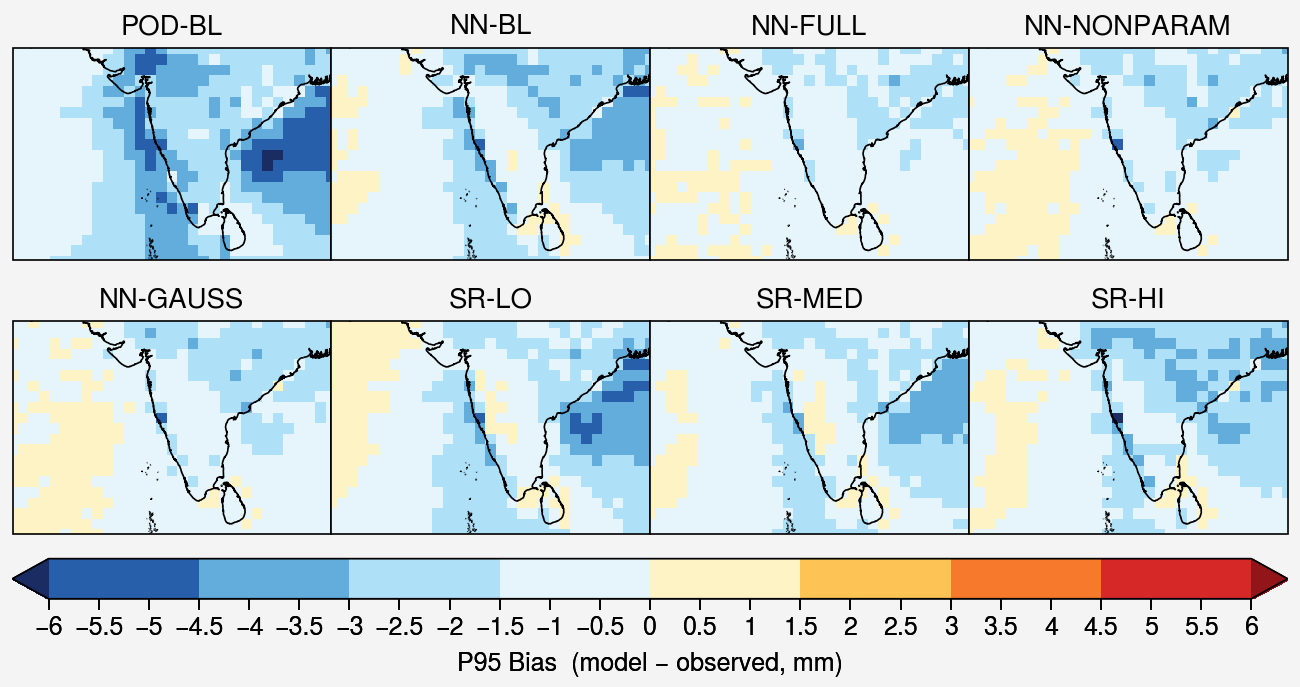

In [11]:
ytrue_ref = next(iter(results.values()))[0]
obs_p95   = ytrue_ref.quantile(0.95,dim='time',skipna=True)

names_ordered = [n for n in MODELDICT if n in results]
n     = len(names_ordered)
ncols = 4
nrows = int(np.ceil(n/ncols))

# Compute bias range for symmetric colorbar
biases = []
for name in names_ordered:
    _,ypred  = results[name]
    pred_p95 = ypred.quantile(0.95,dim='time',skipna=True)
    biases.append(pred_p95 - obs_p95)
vmax = max(float(abs(b).max()) for b in biases)

fig,axs = pplt.subplots(nrows=nrows,ncols=ncols,proj='cyl',figwidth=6.5,share=False,wspace=0)
axs.format(coast=True,latlim=LATRANGE,lonlim=LONRANGE,latlines=5,lonlines=5,grid=False)
m = None
for ax,name,bias in zip(axs,names_ordered,biases):
    m = ax.pcolormesh(bias.lon,bias.lat,bias,
                      cmap='ColdHot',vmin=-vmax,vmax=vmax,levels=11,extend='both')
    ax.format(title=MODELDICT[name]['label'])
for ax in axs[n:]:
    ax.set_visible(False)
fig.colorbar(m,loc='b',label='P95 Bias  (model − observed, mm)',ticks=0.5)
pplt.show()
# fig.save('../figs/fig_S_extremes_p95_bias.jpg')

## Approach 4: Detection skill at multiple thresholds

Define an "extreme event" as any grid-cell/time-step where observed precipitation exceeds a given percentile threshold (75th, 90th, 95th, 99th). For each model and threshold compute the standard binary skill scores:

- **POD** (Probability of Detection) = TP / (TP + FN)
- **FAR** (False Alarm Ratio) = FP / (TP + FP)
- **CSI** (Critical Success Index) = TP / (TP + FP + FN)

A perfect model has POD = 1, FAR = 0, CSI = 1.

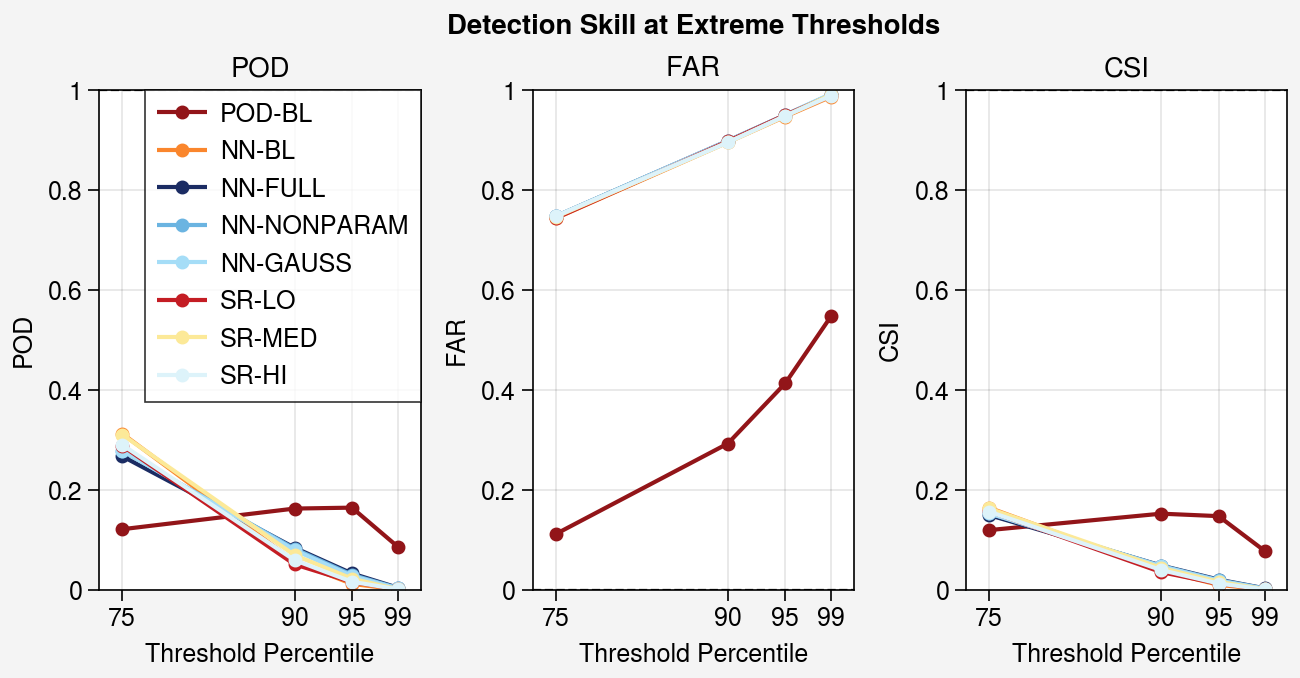

In [12]:
THRESH_PERCENTILES = [75,90,95,99]

ytrue_ref  = next(iter(results.values()))[0]
obs_flat   = ytrue_ref.values.ravel()
valid_mask = np.isfinite(obs_flat)

skill = {}  # name -> {pct -> {'pod','far','csi'}}
for name in [n for n in MODELDICT if n in results]:
    skill[name] = {}
    pred_flat   = results[name][1].values.ravel()
    both_valid  = valid_mask & np.isfinite(pred_flat)
    obs_v       = obs_flat[both_valid]
    pred_v      = pred_flat[both_valid]
    for pct in THRESH_PERCENTILES:
        thresh     = np.nanpercentile(obs_v,pct)
        obs_exc    = obs_v  >= thresh
        pred_exc   = pred_v >= thresh
        TP = np.sum( obs_exc &  pred_exc)
        FP = np.sum(~obs_exc &  pred_exc)
        FN = np.sum( obs_exc & ~pred_exc)
        pod = TP/(TP+FN) if (TP+FN)>0 else np.nan
        far = FP/(TP+FP) if (TP+FP)>0 else np.nan
        csi = TP/(TP+FP+FN) if (TP+FP+FN)>0 else np.nan
        skill[name][pct] = dict(pod=pod,far=far,csi=csi)

names_ordered = [n for n in MODELDICT if n in skill]
score_labels  = {'pod':'POD','far':'FAR','csi':'CSI'}
fig,axs = pplt.subplots(nrows=1,ncols=3,figwidth=6.5,refheight=2.5,share=False)
for ax,(score,slabel) in zip(axs,score_labels.items()):
    for name in names_ordered:
        vals  = [skill[name][p][score] for p in THRESH_PERCENTILES]
        info  = MODELDICT[name]
        ax.plot(THRESH_PERCENTILES,vals,color=info['color'],lw=1.5,marker='o',ms=4,label=info['label'])
    if score == 'far':
        ax.axhline(0,color='k',lw=0.8,linestyle='--')
    else:
        ax.axhline(1,color='k',lw=0.8,linestyle='--')
    ax.format(xlabel='Threshold Percentile',ylabel=slabel,
              title=slabel,xlim=(73,101),ylim=(0,1),grid=True,
              xticks=THRESH_PERCENTILES)
axs[0].legend(loc='ur',ncols=1)
fig.format(suptitle='Detection Skill at Extreme Thresholds')
pplt.show()
# fig.save('../figs/fig_S_extremes_detection.jpg')